# 09. 상태 관리 (State Management)

> 체크포인터에 저장된 상태는 **읽기뿐 아니라 쓰기**도 가능해요. `update_state`, 메시지 ID 보존, history replay — 운영 시 자주 쓰는 기법을 한 번에 정리해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **커스텀 상태(Custom State)** 를 TypedDict로 확장하여 `ask_human` 같은 플래그 필드를 추가할 수 있어요
2. **`update_state()`** 로 그래프 실행 도중 상태를 수동으로 주입하고, `as_node` 파라미터로 특정 노드를 시뮬레이션할 수 있어요
3. **메시지 ID 보존** 을 활용해 기존 메시지를 append 대신 replace하는 원리를 이해하고 도구 파라미터를 수정할 수 있어요
4. **`get_state_history()`** 로 체크포인트 히스토리를 순회하여 특정 시점으로 되돌아가 Replay할 수 있어요

## 사전 지식

- `08-Human-In-The-Loop.ipynb` — `interrupt`, `Command`, Time Travel
- `07-Memory-Checkpointer.ipynb` — `InMemorySaver`, `thread_id`, 체크포인트 개념
- `06-Tools-Integration.ipynb` — `ToolNode`, `tools_condition`, 조건부 엣지


## 개념 설명

지금까지는 `messages` 필드 하나만 있는 단순한 State에 의존해 왔어요. 하지만 복잡한 동작을 정의하려면 **상태에 추가 필드를 더하는 것**이 필요해요.

이번 노트북에서는 세 가지 핵심 기술을 배워요.

| 기술 | 설명 | 활용 시점 |
|------|------|----------|
| Custom State | TypedDict 확장, `ask_human` 같은 플래그 필드 추가 | 노드 분기 조건을 상태로 관리할 때 |
| `update_state()` | 그래프 외부에서 상태를 수동 업데이트 | 운영자 승인/교정, 외부 시스템 응답 주입, 도구 결과 수정 |
| `get_state_history()` | 전체 체크포인트 이력 순회 | 특정 시점 Replay, 롤백 |

> 🔑 **핵심 개념**: LangGraph의 상태(State)는 단순한 dict가 아니에요. `add_messages` 같은 **리듀서(Reducer)** 가 결합된 TypedDict이기 때문에, 동일한 메시지 ID로 업데이트하면 append가 아닌 **replace** 가 일어나요.

```mermaid
flowchart TD
    A["사용자 입력<br/>HumanMessage"] --> B["chatbot 노드<br/>LLM 추론"]
    B --> C{"select_next_node"}
    C -->|"ask_human=True"| D["human 노드<br/>interrupt_before"]
    C -->|"tool_calls 있음"| E["tools 노드<br/>ToolNode"]
    C -->|"종료"| F["END"]
    D --> G["update_state()<br/>외부 응답 주입"]
    G --> B
    E --> B

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef error fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A input
    class B,E process
    class C,G storage
    class D error
    class F output
```


## 환경 설정


In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY, LANGCHAIN_API_KEY 등을 읽어와요
from dotenv import load_dotenv

load_dotenv()


True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택 사항)
# ---------------------------------------------------
# LangSmith에서 그래프 실행 흐름을 시각적으로 추적할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Tutorial-09-State-Management"


---

## 1. Custom State — ask_human 플래그 추가

기존 State는 `messages` 필드 하나였어요. 이번에는 `ask_human: bool` 필드를 추가해서, LLM이 외부 검토자에게 확인을 요청하는 특수 도구를 호출했을 때 플래그를 활성화하는 구조를 만들어볼게요.


In [3]:
from typing import Annotated

from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]
    ask_human: bool


/Users/elixir/dev/lecture/hk-toss/10_langgraph/.venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
from pydantic import BaseModel

class HumanRequest(BaseModel):
    """Forward the conversation to a human reviewer.
    Use when the workflow needs an external decision before continuing.
    Pass the user's 'request' so the reviewer can provide the required input.
    """

    request: str  # 외부 검토자에게 전달할 요청 내용

In [5]:
from langchain_tavily import TavilySearch as TavilySearchResults  # langchain-tavily 패키지 사용 (최신 V1 방식)
from langchain.chat_models import init_chat_model


search_tool = TavilySearchResults(max_results=3)
tools = [search_tool, HumanRequest]
llm = init_chat_model("openai:gpt-4o-mini")

llm_with_tools = llm.bind_tools(tools)

In [6]:
def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])

    ask_human = False

    if response.tool_calls and response.tool_calls[0]["name"] == HumanRequest.__name__:
        ask_human = True

    return State(ask_human=ask_human, messages=[response])

---

## 2. Human 노드와 조건부 분기

Human 노드는 항상 `interrupt_before` 로 중단되는 **자리 표시자(placeholder)** 역할을 해요. 실행 시 사람이 응답을 입력하지 않으면, 자동으로 "응답 없음" ToolMessage를 생성해서 그래프가 계속 진행될 수 있게 해요.


In [7]:
from langchain_core.messages import AIMessage, ToolMessage

# ---------------------------------------------------
# Human 노드와 ToolMessage 생성 헬퍼
# ---------------------------------------------------
# create_response: AIMessage의 tool_call_id에 맞는 ToolMessage를 생성해요
# human_node: interrupt_before로 중단 후, 사람 응답이 없으면 기본값을 넣어요
from langchain_core.messages import AIMessage, ToolMessage


def create_response(response: str, ai_message: AIMessage) -> ToolMessage:
    """AI 메시지의 tool_call_id에 맞는 ToolMessage를 생성해요."""
    print(ai_message.tool_calls)
    return ToolMessage(
        content=response,
        tool_call_id=ai_message.tool_calls[0]["id"],  # ID 매칭 필수!
    )


def human_node(state: State) -> dict:
    """사람의 응답을 기다리는 노드예요.
    interrupt_before로 중단되며, 응답이 없으면 기본 메시지를 삽입해요.
    """
    new_messages = []

    # 마지막 메시지가 ToolMessage가 아닌 경우 = 사람이 응답하지 않은 경우
    if not isinstance(state["messages"][-1], ToolMessage):
        new_messages.append(
            create_response("No response from human.", state["messages"][-1])
        )

    return {
        "messages": new_messages,
        "ask_human": False,  # 플래그를 다시 해제해요
    }

In [8]:
from langgraph.graph import END
from langgraph.prebuilt import tools_condition

def select_next_node(state: State) -> str:
    if state["ask_human"]:
        return "human"
    return tools_condition(state)



---

## 3. 그래프 조립 및 시각화


In [9]:
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# ---------------------------------------------------
# 그래프 빌더 조립
# ---------------------------------------------------
# interrupt_before=["human"]: human 노드 실행 직전에 중단해서
#   외부에서 update_state()로 검토자 응답을 주입할 수 있어요
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# 그래프 빌더 초기화
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=[search_tool]))  # HumanRequest는 제외!
graph_builder.add_node("human", human_node)

# 조건부 엣지: chatbot → select_next_node → human/tools/END
graph_builder.add_conditional_edges(
    "chatbot",
    select_next_node,
    {"human": "human", "tools": "tools", END: END},
)

# 단방향 엣지
graph_builder.add_edge("tools", "chatbot")   # 도구 실행 후 chatbot으로 돌아와요
graph_builder.add_edge("human", "chatbot")   # 외부 응답 주입 후 chatbot으로 돌아와요
graph_builder.add_edge(START, "chatbot")     # 시작점

# 체크포인터 + interrupt_before 설정
memory = MemorySaver()
graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["human"],  # human 노드 직전에 중단!
)

# 그래프 컴파일 완료!

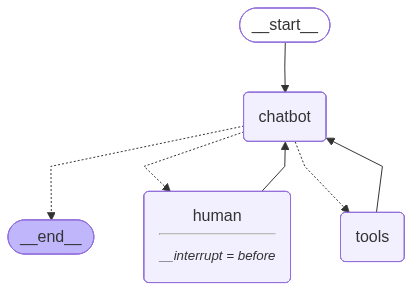

In [10]:
from IPython.display import Image, display

graph

---

## 4. 외부 응답을 상태에 주입하기 — update_state()와 as_node

`update_state()`는 그래프 외부에서 상태를 수동으로 업데이트하는 메서드예요. 여기서 중요한 것은 그래프가 멈춘 뒤 **외부 시스템이나 사람이 만든 결과를 마치 특정 노드가 방금 반환한 값처럼 체크포인트에 기록하고 이어 실행하는 방법**이에요.

실무에서는 상담원이 관리자 콘솔에서 입력한 답변, Slack 승인 메시지, 운영자가 수정한 SQL/검색 쿼리, 장애 복구 중 수동으로 보정한 상태처럼 **그래프 밖에서 만들어진 결정**을 다시 그래프 안으로 넣어야 할 때가 있어요. 이때 `update_state()`를 사용하면 기존 체크포인트를 직접 덮어쓰는 것이 아니라, 리듀서를 적용한 **새 체크포인트**를 만들고 그 지점부터 실행을 이어갈 수 있어요.

이번 예제는 외부 검토자가 입력한 응답을 `ToolMessage`로 주입하는 흐름을 사용해 이 패턴을 보여줘요. 일반적인 승인/거부 HITL만 필요하다면 `interrupt()` + `Command(resume=...)` 또는 `HumanInTheLoopMiddleware`가 더 자연스럽지만, 응답을 `ToolMessage`로 직접 구성하거나 도구 호출 인자 자체를 교정해야 할 때는 `update_state()`가 더 세밀한 제어를 제공해요.


In [11]:
# ---------------------------------------------------
# 1단계: 외부 검토가 필요한 메시지로 그래프 실행
# ---------------------------------------------------
# LLM이 HumanRequest 도구를 호출하면 interrupt_before=["human"]에서 중단돼요
user_input = "고객 환불 요청을 처리하기 전에 운영자 확인이 필요합니다. 검토를 요청해 주세요."

# 스레드 ID 설정 (대화 세션 구분)
config = {"configurable": {"thread_id": "thread-external-review"}}

# 그래프 스트리밍 실행
events = graph.stream(
    {"messages": [("user", user_input)], "ask_human": False},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

고객 환불 요청을 처리하기 전에 운영자 확인이 필요합니다. 검토를 요청해 주세요.
================================== Ai Message ==================================
Tool Calls:
  HumanRequest (call_GdHZPKO674tAxKXWa7fR3hh5)
 Call ID: call_GdHZPKO674tAxKXWa7fR3hh5
  Args:
    request: 고객 환불 요청을 처리하기 전에 운영자 확인 필요합니다. 이 요청을 검토해 주세요.


In [12]:
# ---------------------------------------------------
# 2단계: 그래프 상태 확인 — 어디서 중단됐는지
# ---------------------------------------------------
snapshot = graph.get_state(config)

print("다음 실행 노드:", snapshot.next)  # ('human',) 이어야 해요
print("ask_human 플래그:", snapshot.values["ask_human"])  # True 이어야 해요

다음 실행 노드: ('human',)
ask_human 플래그: True


In [13]:
# ---------------------------------------------------
# 3단계: 외부 응답 주입 — update_state()
# ---------------------------------------------------
# tool_call_id를 정확히 매칭해야 해요!
# AI 메시지의 tool_calls[0]["id"]를 사용해요

# 직전 AI 메시지 추출
ai_message = snapshot.values["messages"][-1]

# 외부에서 들어온 응답 내용
# 예: 상담원/관리자 콘솔/Slack 승인 플로우에서 받은 메시지
external_response = (
    "운영자 확인 결과, 최근 7일 이내 결제 건이면 전액 환불이 가능합니다. "
    "고객에게 환불 처리 가능 여부를 안내하고, 주문 번호와 결제 수단 확인을 요청하세요."
)

# ToolMessage 생성 (tool_call_id 매칭 필수!)
tool_message = create_response(external_response, ai_message)

# 상태 업데이트: as_node="human"으로 human 노드가 이 값을 반환한 것처럼 처리
graph.update_state(
    config,
    {"messages": [tool_message], "ask_human": False},
    as_node="human",  # 다음 실행 위치를 human 노드의 후속 노드로 정렬해요
)

# 상태 업데이트 완료!
print("업데이트 후 다음 노드:", graph.get_state(config).next)

[{'name': 'HumanRequest', 'args': {'request': '고객 환불 요청을 처리하기 전에 운영자 확인 필요합니다. 이 요청을 검토해 주세요.'}, 'id': 'call_GdHZPKO674tAxKXWa7fR3hh5', 'type': 'tool_call'}]
업데이트 후 다음 노드: ('chatbot',)


In [14]:
# ---------------------------------------------------
# 4단계: 외부 응답을 받은 후 그래프 재개
# ---------------------------------------------------
# None을 입력하면 현재 상태에서 이어서 실행해요
events = graph.stream(None, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================= Tool Message =================================

운영자 확인 결과, 최근 7일 이내 결제 건이면 전액 환불이 가능합니다. 고객에게 환불 처리 가능 여부를 안내하고, 주문 번호와 결제 수단 확인을 요청하세요.
================================== Ai Message ==================================

운영자 확인 결과, 최근 7일 이내 결제 건에 대해서는 전액 환불이 가능합니다. 고객에게 환불 처리 가능 여부를 안내하고, 주문 번호와 결제 수단을 확인해 달라고 요청하세요.


---

## 5. 도구 파라미터 수정 — 메시지 ID 보존

그래프가 도구 노드에서 중단됐을 때, LLM이 생성한 **검색 쿼리나 도구 인자가 마음에 들지 않으면 수정**할 수 있어요.

`add_messages` 리듀서의 특성을 활용해요: **같은 ID로 메시지를 update_state하면 append가 아니라 replace**가 일어나요.

```mermaid
flowchart LR
    A["interrupt_before tools"] --> B["기존 AIMessage<br/>query: 원본 쿼리"]
    B --> C["동일 ID로<br/>새 AIMessage 생성"]
    C --> D["update_state() 호출"]
    D --> E["리듀서: ID 일치<br/>→ replace"]
    E --> F["그래프 재개<br/>수정된 쿼리로 검색"]

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class A,B process
    class C,D,E storage
    class F output
```

### add_messages 리듀서의 ID 기반 동작 요약

| 새 메시지의 ID | 기존 메시지에 같은 ID | 결과 |
|---------------|---------------------|------|
| 없음 (자동 생성) | - | **추가(append)**: 새 메시지가 리스트 끝에 추가 |
| `id="msg-1"` | 없음 | **추가(append)**: 새 메시지가 리스트 끝에 추가 |
| `id="msg-1"` | 있음 | **교체(replace)**: 기존 메시지를 새 메시지로 대체 |


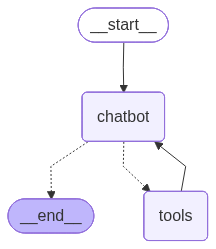

In [47]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_tavily import TavilySearch as TavilySearchResults  # langchain-tavily 패키지 사용 (최신 V1 방식)
from langchain.chat_models import init_chat_model
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

class SearchState(TypedDict):
    messages: Annotated[list, add_messages]

search_tool_only = TavilySearchResults(max_results=2)
search_tools = [search_tool_only]

search_llm = init_chat_model("openai:gpt-4o-mini")

search_llm_with_tools = search_llm.bind_tools(
    search_tools,
    parallel_tool_calls=False
)

def search_chatbot(state: SearchState):
    return SearchState(messages=[search_llm_with_tools.invoke(state["messages"])])

# 그래프 조립
search_builder = StateGraph(SearchState)

search_builder.add_node("chatbot", search_chatbot)
search_builder.add_node("tools", ToolNode(tools=search_tools))

search_builder.add_edge(START, "chatbot")
search_builder.add_edge("tools", "chatbot")
search_builder.add_conditional_edges("chatbot", tools_condition)

search_memory = MemorySaver()
search_graph = search_builder.compile(checkpointer=search_memory)

search_graph


In [48]:
import uuid

thread_id = str(uuid.uuid4())[:8]
print(thread_id)
search_config = RunnableConfig(configurable={"thread_id": thread_id})

question = "Langchain에 대해 공식 사이트에서 검색해서 알려주세요"

events = search_graph.stream(
    {"messages": [("user", question)]},
    search_config,
    interrupt_before=["tools"],
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

3e64a080
================================ Human Message =================================

Langchain에 대해 공식 사이트에서 검색해서 알려주세요
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_yugi9WFF6Lxblq2JnNcDxEBG)
 Call ID: call_yugi9WFF6Lxblq2JnNcDxEBG
  Args:
    query: Langchain 공식 사이트
    include_domains: ['langchain.com']
    search_depth: advanced


In [49]:
search_snapshot = search_graph.get_state(search_config)
existing_messages = search_snapshot.values["messages"][-1]
existing_messages

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 1198, 'total_tokens': 1230, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fff3498a90', 'id': 'chatcmpl-DggCOqSqnScaFNGhUtY3Wxv1Mr7rg', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e387f-cdd6-7ce0-93d5-b2470887eb78-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Langchain 공식 사이트', 'include_domains': ['langchain.com'], 'search_depth': 'advanced'}, 'id': 'call_yugi9WFF6Lxblq2JnNcDxEBG', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1198, 'output_tokens': 32, 'total_tokens': 1230, 'input_token_details': {'audio': 

In [51]:
from langchain_core.messages import AIMessage

AIMessage
new_tool_call = existing_messages.tool_calls[0].copy()
new_tool_call["args"] = {"query": "LangChain 대해서 알려줘. site:github.com/langchain-ai/langchain"}

new_tool_call

new_message = AIMessage(
    content= existing_messages.content,
    tool_calls = [new_tool_call],
    id=existing_messages.id
)
new_message


AIMessage(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019e387f-cdd6-7ce0-93d5-b2470887eb78-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'LangChain 대해서 알려줘. site:github.com/langchain-ai/langchain'}, 'id': 'call_yugi9WFF6Lxblq2JnNcDxEBG', 'type': 'tool_call'}], invalid_tool_calls=[])

In [52]:
search_graph.update_state(
    search_config,
    {"messages": [new_message]},
    as_node="chatbot"
)

updated_tool_calls = search_graph.get_state(search_config).values["messages"][-1].tool_calls
print("업데이트 후 쿼리:", updated_tool_calls[0]["args"])


업데이트 후 쿼리: {'query': 'LangChain 대해서 알려줘. site:github.com/langchain-ai/langchain'}


In [ ]:
evnets = search_graph.stream(None, search_config, )

---

## 6. 상태 히스토리와 Replay — get_state_history()

지금까지 `update_state()`로 상태를 수동으로 수정하는 방법을 배웠어요. 이제 한 걸음 더 나아가, 특정 과거 시점으로 되돌아가서 **다른 선택을 해보는** 방법을 알아볼게요. 마치 게임의 세이브 포인트를 불러오는 것과 같아요.

`get_state_history(config)`는 특정 스레드의 모든 체크포인트를 **역순**(최신 → 과거)으로 순회해요. 원하는 시점을 골라 해당 상태에서 **Replay**할 수 있어요.


In [21]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 전체 상태 히스토리 조회
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


In [22]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: Replay 대상 메시지 확인
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


In [23]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 과거 시점의 쿼리를 다른 값으로 교체하여 Replay
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


In [24]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 수정된 과거 시점에서 새 브랜치로 Replay 실행
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


---

## 7. 실습 — 커스텀 필드로 대화 감정 추적하기

아래 TODO를 완성해서 `mood` 필드를 State에 추가하고, chatbot 노드가 응답할 때마다 현재 대화 분위기를 추적해보세요.


In [25]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain.chat_models import init_chat_model

mood_llm = init_chat_model("openai:gpt-4o-mini")

import uuid

# ============================================================
# TODO: mood 필드가 있는 커스텀 State를 완성하고
#       chatbot 노드가 매 응답마다 mood를 업데이트하게 만들어보세요
#
# 힌트:
#   - TypedDict에 mood: str 필드를 추가해요 (예: "neutral", "positive", "negative")
#   - chatbot 노드에서 LLM 응답 내용에 따라 mood를 설정해요
#   - get_state()로 최종 mood 값을 확인해요
#
# 예상 결과:
#   - 긍정적 대화 후: mood = "positive"
#   - 부정적 대화 후: mood = "negative"
# ============================================================

# 여기에 코드를 작성하세요

    # TODO: LLM 응답을 생성하고, 응답 내용에 따라 mood를 설정해보세요


---

## 7. 가상의 실무 시나리오 — while 루프로 이어지는 승인/거부 대화

이 마지막 예제의 목표는 **HITL(Human-in-the-loop)** 과 **State Management** 를 한 번에 체감하는 것입니다.

사용자가 일반 질문을 하면 LLM이 바로 답합니다. 하지만 환불, 결제, 삭제, 메일 전송처럼 실제 행동으로 이어질 수 있는 요청이면 LLM이 먼저 멈춰서 사용자에게 **`승인` 또는 `거부`** 를 요청합니다.

```mermaid
flowchart TD
    A["사용자 입력"] --> B["llm_review_request<br/>승인 필요 여부 판단"]
    B --> C{"승인 필요?"}
    C -->|"아니오"| D["AI 즉시 답변"]
    C -->|"예"| E["human_approval 앞에서 중단"]
    E --> F["get_state()로<br/>중단 지점 확인"]
    F --> G["사용자 승인/거부 입력"]
    G --> H["update_state(..., as_node='human_approval')"]
    H --> I["stream(None, config)로 재개"]
    I --> J["answer_after_approval<br/>최종 답변"]
```


### 실행 방법

아래 셀들을 위에서 아래로 차례대로 실행하세요.

1. State와 구조화 출력 모델을 정의합니다.
2. LLM에게 “승인이 필요한 요청인지” 판단하게 하는 프롬프트를 설정합니다.
3. 그래프 노드 함수를 정의합니다.
4. 그래프를 컴파일하고 같은 `thread_id`로 대화를 이어갑니다.
5. 마지막 while 루프 셀에서 직접 입력해 봅니다.

예시 입력:

```text
LangGraph의 State가 뭐야?
배송이 늦었으니 환불 처리해줘.
내 계정을 삭제해줘.
```

승인 요청이 나오면 정확히 다음 둘 중 하나로 답하세요.

```text
승인
거부
```

종료하려면 `q`, `quit`, `exit` 중 하나를 입력하면 됩니다.

> ⚠️ 이 예제는 실제 환불, 삭제, 메일 발송 같은 외부 작업을 실행하지 않습니다. 승인/거부 이후에 어떤 메시지를 만들지 보여주는 수업용 시뮬레이션입니다.


In [53]:
from operator import add
from typing import Annotated, Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
import uuid

# state 정의

class ApprovalChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    pending_request: str
    approval_reason: str
    approval_question: str
    approval_decision: str
    audit_log: Annotated[list[str], add]

class ApprovalPlan(BaseModel):
    """LLM이 이번 사용자 요청을 어떻게 처리할 지 구조화해서 반환"""
    needs_approval: bool = Field(description="사용자의 명시적 승인/거부가 필요한 요청이면 True")
    reason: str = Field(description="승인이 필요한 이유. 필요 없으면 빈 문자열")
    approval_question: str = Field(description="사용자에게 보여줄 승인/거부 질문. 필요 없으면 빈 문자열")
    safe_replay: str = Field(description="승인이 필요 없는 경우 바로 사용자에게 보낼 답변.")


### 2단계 — LLM에게 승인 필요 여부를 판단하게 하기

이 셀에서는 LLM에게 다음 역할을 맡깁니다.

- 일반 질문이면 바로 답변하기
- 돈, 삭제, 외부 발송, 예약 확정처럼 실제 행동을 일으키는 요청이면 승인 게이트로 보내기
- 승인 게이트로 보낼 때는 반드시 사용자가 **`승인` 또는 `거부`** 로 답하게 만들기

여기서 `with_structured_output(ApprovalPlan)`을 사용하므로, LLM 응답을 문자열이 아니라 `ApprovalPlan` 객체처럼 다룰 수 있습니다.


In [54]:
approval_llm = init_chat_model("openai:gpt-4o-mini")

approval_planner = approval_llm.with_structured_output(ApprovalPlan)

APPROVAL_SYSTEM_PROMPT = """
너는 LangGraph 수업용 한국어 챗봇이다.
사용자의 최신 요청을 보고 승인이 필요한지 판단한다.

승인이 필요한 요청의 예:
- 환불, 결제, 주문 취소처럼 돈이나 거래에 영향을 주는 요청
- 계정 삭제, 데이터 삭제, 권한 변경처럼 되돌리기 어려운 요청
- 이메일/문자 발송, 예약 확정처럼 외부 시스템에 행동을 일으키는 요청

승인이 필요하면:
- needs_approval=true
- approval_question에는 반드시 사용자가 정확히 '승인' 또는 '거부'로 답하도록 요청한다
- safe_reply는 빈 문자열로 둔다

승인이 필요하지 않으면:
- needs_approval=false
- safe_reply에 바로 답변한다
- reason과 approval_question은 빈 문자열로 둔다
""".strip()

### 3단계 — 첫 번째 노드: LLM 검토 노드

`llm_review_request` 노드는 그래프의 첫 번째 실제 작업 노드입니다.

이 노드가 하는 일은 두 가지입니다.

1. 가장 최근 사용자 메시지를 찾습니다.
2. LLM에게 “이 요청은 승인이 필요한가?”를 물어봅니다.

결과에 따라 State 업데이트가 달라집니다.

- 승인이 필요 없으면: AI 답변 메시지를 `messages`에 추가하고 종료 방향으로 갑니다.
- 승인이 필요하면: 승인 질문을 `messages`에 추가하고, `approval_question` 필드를 채워서 다음 라우팅에서 `human_approval`로 가게 합니다.


In [ ]:
def latest_human_text(messages: list[BaseModel]) -> str:
    for message in reversed(messages):
        if message.type == "human":
            return message.content
    return ""

def llm_review_request(state: ApprovalChatState) -> dict:
    user_text = latest_human_text(state["messages"])

    plan = approval_planner.invoke(
      [
        SystemMessage(content=APPROVAL_SYSTEM_PROMPT),
        HumanMessage(content=f"최신 사용자 요청: {user_text}")
      ]
    )

    if plan.need_apploval:
        approval_question = plan.approval_question.strip()
        

### 4단계 — 라우팅과 승인 처리 노드

여기서 핵심은 `human_approval` 노드입니다.

이 노드는 실제로 사용자의 입력을 직접 받지 않습니다. 대신 그래프를 컴파일할 때 `interrupt_before=["human_approval"]`를 설정해서, 이 노드가 실행되기 **직전**에 그래프를 멈춥니다.

그러면 while 루프 쪽에서 다음 순서로 처리합니다.

1. `snapshot = graph.get_state(config)`로 멈춘 상태를 확인합니다.
2. 사용자가 `승인` 또는 `거부`를 입력합니다.
3. `graph.update_state(..., as_node="human_approval")`로 그 판단을 주입합니다.
4. `graph.stream(None, config)`로 `human_approval` 이후 노드부터 재개합니다.


In [29]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 4단계: 라우팅 함수 + 승인 처리 노드 정의
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


### 5단계 — 그래프 조립과 체크포인터 설정

이제 노드와 엣지를 연결합니다.

가장 중요한 설정은 두 가지입니다.

```python
checkpointer=MemorySaver()
interrupt_before=["human_approval"]
```

- `MemorySaver()`는 같은 `thread_id` 안에서 상태 체크포인트를 저장합니다.
- `interrupt_before`는 승인 노드 직전에 그래프를 멈추게 합니다.

그래프가 멈춘 뒤에는 `get_state(config)`로 `snapshot.next`를 확인할 수 있습니다. 승인 대기 중이면 `snapshot.next == ("human_approval",)`가 됩니다.


In [30]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 5단계: 그래프 조립 + compile
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


### 6단계 — 출력 도우미 함수

`stream(..., stream_mode="values")`는 실행 중간중간 전체 State 값을 보여줍니다. 그런데 매번 전체 메시지를 출력하면 이전 메시지까지 반복해서 보이기 때문에 학생 입장에서는 헷갈릴 수 있습니다.

그래서 아래 함수는 **이번 실행에서 새로 추가된 AI 메시지만** 출력합니다.


In [31]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 6단계: 새 AI 메시지만 출력하는 도우미 함수
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


### 7단계 — while 루프로 직접 대화하기

이제 실제로 대화해 봅니다.

일반 질문을 입력하면 LLM이 바로 답합니다. 승인이 필요한 요청을 입력하면 다음 일이 일어납니다.

1. LLM이 승인 질문을 출력합니다.
2. 그래프가 `human_approval` 직전에 멈춥니다.
3. while 루프가 사용자에게 `승인` 또는 `거부`를 묻습니다.
4. 입력값이 `update_state(..., as_node="human_approval")`로 State에 기록됩니다.
5. `stream(None, chat_config)`로 그래프가 이어서 실행됩니다.

> 실습 팁: 먼저 `LangGraph의 State가 뭐야?`를 입력해 보고, 다음에는 `배송이 늦었으니 환불 처리해줘.`를 입력해 보세요.


In [32]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 7단계: while 루프로 대화 실행
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


### 8단계 — 저장된 State 확인하기

대화를 몇 번 나눈 뒤 아래 셀을 실행해 보세요.

`get_state(chat_config)`는 현재 `thread_id`의 최신 체크포인트를 반환합니다. 여기서 `values`를 보면 메시지, 승인 대기 정보, 감사 로그가 모두 State로 저장되어 있음을 확인할 수 있습니다.


In [33]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 8단계: 현재 체크포인트 State 확인
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


---

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **Custom State**: TypedDict에 `ask_human: bool` 같은 추가 필드를 넣어서, 노드 분기 조건을 상태로 관리할 수 있어요
- **`update_state(config, values, as_node=)`**: 그래프 외부에서 상태를 수동 업데이트해요. `as_node`로 특정 노드가 실행된 것처럼 처리할 수 있어요
- **ToolMessage 페어링**: `tool_call_id`가 직전 AI 메시지의 `tool_calls[0]["id"]`와 반드시 일치해야 해요
- **메시지 ID 보존**: `add_messages` 리듀서는 같은 ID의 메시지를 replace해요. 도구 파라미터를 수정할 때 `id=existing_message.id`를 유지해야 해요
- **`get_state_history()`**: 전체 체크포인트 히스토리를 역순으로 순회해서, 특정 시점을 선택하고 Replay할 수 있어요
- **승인/거부 HITL 흐름**: `interrupt_before`, `get_state`, `update_state(as_node=...)`, `stream(None, config)`를 조합하면 외부 판단을 State에 주입하고 이어 실행하는 흐름을 체험할 수 있어요


## 다음 노트북 예고

다음 `Part 03 / 01-Workflows-vs-Agents.ipynb`에서는 **LangGraph로 구현할 수 있는 6가지 워크플로우 패턴**을 배워요. 반복, 병렬 분기, 라우팅 등 실무에서 자주 쓰는 패턴들을 코드로 직접 구현해볼게요.
